<a href="https://colab.research.google.com/github/gowebUSA/Palomar-ComSci/blob/main/Go_A3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CSCI 290 Mchine Learning
Assignment #3
Richard Go

A1 Read the World Happiness Data (2017) from URL
https://raw.githubusercontent.com/ebubekiraygun/World-Happiness-Data-on-Python/master/2017.csv

In [5]:
import pandas as pd

url = "https://raw.githubusercontent.com/ebubekiraygun/World-Happiness-Data-on-Python/master/2017.csv"
rc = pd.read_csv(url)

# Rename columns
rc.rename(columns={
    "Happiness.Rank": "Happiness_Rank",
    "Happiness.Score": "Happiness_Score",
    "Whisker.high": "w_high",
    "Whisker.low": "w_low",
    "Economy..GDP.per.Capita.": "Economy",
    "Health..Life.Expectancy.": "Health",
    "Trust..Government.Corruption.": "Trust",
    "Dystopia.Residual": "Dystopia"
}, inplace=True)

print(rc.columns)

rc.head()

Index(['Country', 'Happiness_Rank', 'Happiness_Score', 'w_high', 'w_low',
       'Economy', 'Family', 'Health', 'Freedom', 'Generosity', 'Trust',
       'Dystopia'],
      dtype='object')


,Country,Happiness_Rank,Happiness_Score,w_high,w_low,Economy,Family,Health,Freedom,Generosity,Trust,Dystopia
0,Norway,1,7.537,7.594445,7.479556,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027
1,Denmark,2,7.522,7.581728,7.462272,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707
2,Iceland,3,7.504,7.622030,7.385970,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715
3,Switzerland,4,7.494,7.561772,7.426227,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716
4,Finland,5,7.469,7.527542,7.410458,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2.430182


A2 Please write a code which generates the plot - Economy vs. Happiness_Score (similar to
the following)


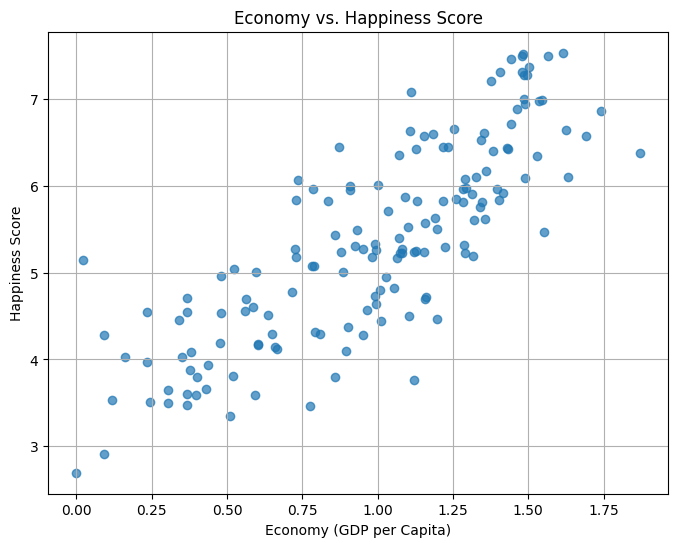

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(rc["Economy"], rc["Happiness_Score"], alpha=0.7) #uses scatter chart
plt.xlabel("Economy (GDP per Capita)")    #label x-axis
plt.ylabel("Happiness Score")             #labe 7-axis
plt.title("Economy vs. Happiness Score")
plt.grid(True)
plt.show()


A3. Please write a code which generates the plot - Freedom vs. Happiness_Score (similar to the
following):
A4. Please write a code which generates the plot - Happiness_Score vs. Health (similar to the
following):


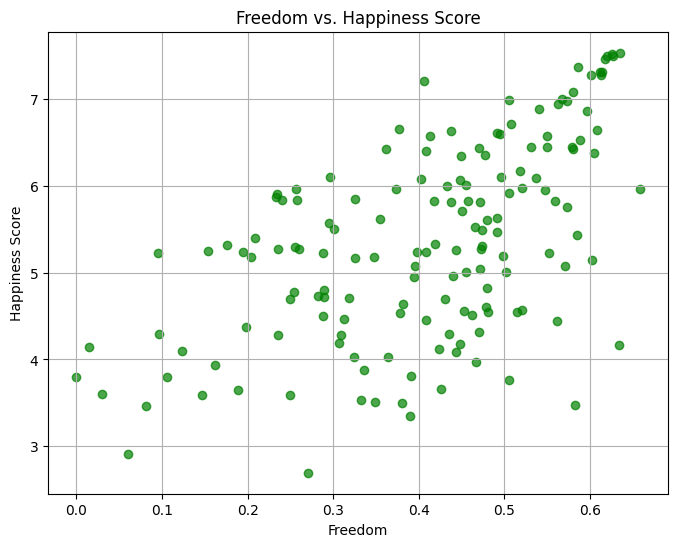

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(rc["Freedom"], rc["Happiness_Score"], alpha=0.7, color='green')
plt.xlabel("Freedom")    #sets x-axis
plt.ylabel("Happiness Score")      #sets xyaxis
plt.title("Freedom vs. Happiness Score")
plt.grid(True)    #add grid
plt.show()


A4. Please write a code which generates the plot - Happiness_Score vs. Health (similar to the
following):


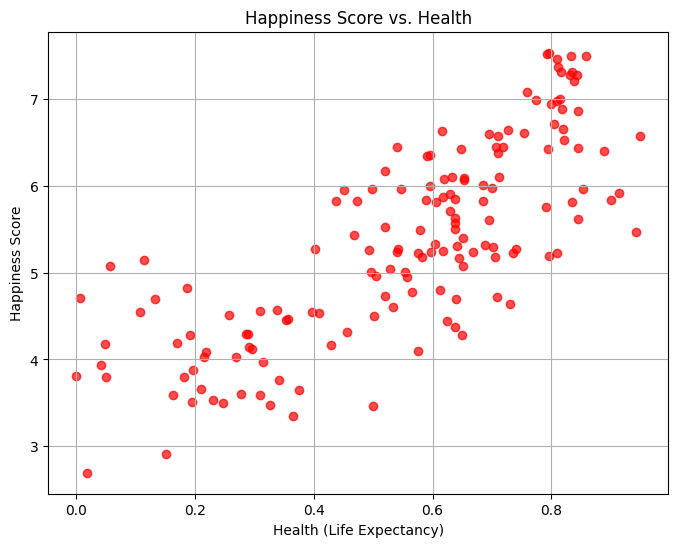

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(rc["Health"], rc["Happiness_Score"], alpha=0.7, color='red')
plt.xlabel("Health (Life Expectancy)")   #sets x-axis
plt.ylabel("Happiness Score")            #sets y-axis
plt.title("Happiness Score vs. Health")
plt.grid(True)     #use grid for better alignment
plt.show()


B1. The following URL contains a historical income vs. life expectancy dataset:
https://raw.githubusercontent.com/gheniabla/datasets/master/life_exp_income_population.csv
Using the information provided by this data, please create an Income vs. Life Expectancy by
Region & Population Plot.
The plot shall be similar to the attached figure. Please include your name on the Title.import pandas as pd

In [ ]:
#Get column header names
import pandas as pd

url = "https://raw.githubusercontent.com/gheniabla/datasets/master/life_exp_income_population.csv"
rc = pd.read_csv(url)

print(rc.columns)

Index(['country', 'region', 'income', 'income_level', 'life_exp', 'co2',
       'co2_change', 'population'],
      dtype='object')


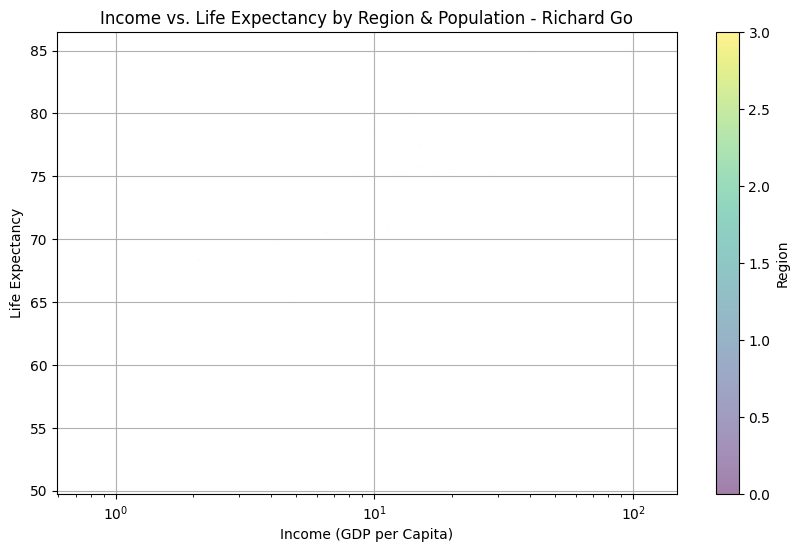

In [ ]:
import pandas as pd

rc2_url = "https://raw.githubusercontent.com/gheniabla/datasets/master/life_exp_income_population.csv"
rc2 = pd.read_csv(rc2_url)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(rc2["income"], rc2["life_exp"],
                       c=rc2["region"].astype('category').cat.codes,
                       s=rc2["population"]/1000000,
                       alpha=0.5, cmap="viridis")
plt.xscale("log")
plt.xlabel("Income (GDP per Capita)")
plt.ylabel("Life Expectancy")
plt.title("Income vs. Life Expectancy by Region & Population - Richard Go")
plt.colorbar(label="Region")
plt.grid(True)
plt.show()


B2. Please create a violin plot: Region vs. Income

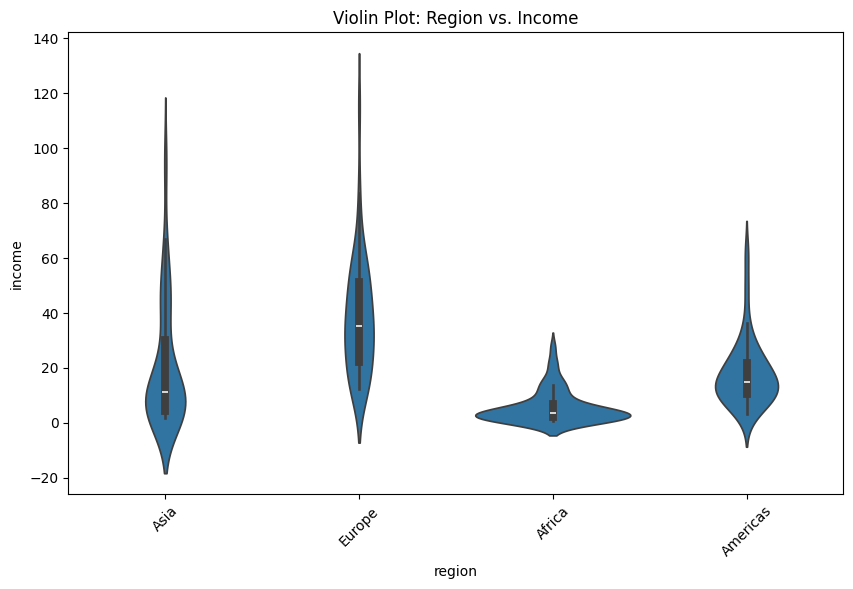

In [ ]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.violinplot(x="region", y="income", data=rc2)
plt.xticks(rotation=45)
plt.title("Violin Plot: Region vs. Income")
plt.show()


C1. Please create a function draw_with_handwritten(str). It draws the text(one word) provided
as the input parameter using the A_Z-HandwrittenData.csv.zip dataset.
As the demonstration, please draw your last name ( just one word & uppercase).

In [15]:
import pandas as pd

df2_url = "https://drive.google.com/file/d/1DkVAHkHCLcjTfBnjCBZ39c7W7q--3cqD/view?usp=drive_link"
df2 = pd.read_csv(df2_url)

HTTPError: HTTP Error 401: Unauthorized

In [17]:
# C1: Draw text using A_Z-HandwrittenData.csv
import numpy as np
import zipfile
import requests
import io
import matplotlib.pyplot as plt

# Download and extract dataset
url = "https://palomar.instructure.com/courses/55072/files/10747665/download?download_frd=1"
r = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall()

# Load dataset
letters_df = pd.read_csv("A_Z-HandwrittenData.csv", header=None)

# Function to draw handwritten letters
def draw_with_handwritten(letter):
    ascii_val = ord(letter) - 65
    samples = letters_df[letters_df.iloc[:, 0] == ascii_val].iloc[:, 1:].values[:1]
    for sample in samples:
        plt.imshow(sample.reshape(28, 28), cmap="gray")
        plt.title(f"Handwritten Letter: {letter}")
        plt.axis("off")
        plt.show()

# Demonstration: Draw "G" for Go
draw_with_handwritten("G")


BadZipFile: File is not a zip file

"C:\Users\849201\Downloads\Semester calendar.xlsx"

In [ ]:
import zipfile

file_path = r"C:\Users\849201\Downloads\A_Z-HandwrittenData.csv.zip"  # Use correct path

try:
    with zipfile.ZipFile(file_path, 'r') as zip_ref:
        zip_ref.extractall()
    print("✅ File extracted successfully!")
except zipfile.BadZipFile:
    print("❌ Error: The file is not a valid ZIP archive.")
except FileNotFoundError:
    print("❌ Error: File not found. Check the file path.")
except PermissionError:
    print("❌ Error: Permission denied. Try running as administrator.")
except Exception as e:
    print(f"❌ Unknown error: {e}")


❌ Error: File not found. Check the file path.


In [10]:
import os

downloads_path = r"C:\Users\849201\Downloads"  # Update with your actual username
files = os.listdir(downloads_path)

print(files)  # Show all files in Downloads folder


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\849201\\Downloads'

In [ ]:
file_path = r"C:\Users\849201\Downloads\A_Z-HandwrittenData.csv.zip"

try:
    with open(file_path, "rb") as f:
        print("✅ File opened successfully!")
except FileNotFoundError:
    print("❌ File still not found. Something is wrong with the path.")


❌ File still not found. Something is wrong with the path.
